In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
 
from sklearn.model_selection import train_test_split  # noqa: F401 (kept for reference; not used for time series)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
 
from xgboost import XGBRegressor
 
import tensorflow as tf  # noqa: F401
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
 

# Load dataset 

In [2]:
df = pd.read_csv('all_stations.csv')

In [3]:
df.head(5)

,fecha,Barcelona_fabra,Barcelona,Sabadell_aero,Garriga,Castellar,Llica,el_Mogent,Mogoda,Gramenet
0,2003-01-01,0.0,0.0,0.0,0.254,0.0327,0.155,0.3985,0.120,3.6275
1,2003-01-02,0.0,0.0,NaN,0.254,0.0281,0.151,0.3745,0.106,3.9471
2,2003-01-03,0.0,0.0,NaN,0.246,0.0225,0.145,0.3750,0.101,4.0174
3,2003-01-04,0.0,0.0,0.0,0.251,0.0300,0.145,0.3720,0.099,3.9316
4,2003-01-05,18.1,16.4,2.1,0.241,0.0328,0.146,0.3686,0.097,3.7913


In [4]:
df.shape

(2922, 10)

In [5]:
df.info

<bound method DataFrame.info of            fecha  Barcelona_fabra  Barcelona  Sabadell_aero  Garriga  \
0     2003-01-01              0.0        0.0            0.0    0.254   
1     2003-01-02              0.0        0.0            NaN    0.254   
2     2003-01-03              0.0        0.0            NaN    0.246   
3     2003-01-04              0.0        0.0            0.0    0.251   
4     2003-01-05             18.1       16.4            2.1    0.241   
...          ...              ...        ...            ...      ...   
2917  2010-12-27              0.0        0.0            0.0    0.238   
2918  2010-12-28              0.0        0.0            0.0    0.234   
2919  2010-12-29              NaN        0.0            NaN    0.223   
2920  2010-12-30              8.9        4.4            NaN    0.211   
2921  2010-12-31              1.9        1.0            NaN    0.214   

      Castellar  Llica  el_Mogent  Mogoda  Gramenet  
0      0.032700  0.155   0.398500   0.120  3.6275

In [6]:
df.describe()

,Barcelona_fabra,Barcelona,Sabadell_aero,Garriga,Castellar,Llica,el_Mogent,Mogoda,Gramenet
count,2679.000000,2699.000000,2516.000000,2922.000000,1789.000000,2922.000000,2309.000000,2852.000000,2922.000000
mean,1.698470,1.539941,1.266494,0.283581,0.195427,0.105649,0.479607,0.119630,4.421081
std,6.116616,5.440818,5.539629,0.856069,0.613047,0.085916,0.567170,0.377305,4.311695
min,0.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.014000,0.000000,0.764272
25%,0.000000,0.000000,0.000000,0.046000,0.022900,0.045000,0.274500,0.000000,2.710300
50%,0.000000,0.000000,0.000000,0.085000,0.046200,0.083000,0.350600,0.024000,3.255550
75%,0.100000,0.000000,0.000000,0.231000,0.102444,0.146000,0.529200,0.079000,4.514250
max,95.400000,112.600000,121.900000,19.776000,13.247163,0.680000,15.605600,8.620000,86.495900


In [7]:
df.isnull().sum()

fecha                 0
Barcelona_fabra     243
Barcelona           223
Sabadell_aero       406
Garriga               0
Castellar          1133
Llica                 0
el_Mogent           613
Mogoda               70
Gramenet              0
dtype: int64

In [8]:
df.dropna(inplace=True)

In [9]:
df.isnull().sum()

fecha              0
Barcelona_fabra    0
Barcelona          0
Sabadell_aero      0
Garriga            0
Castellar          0
Llica              0
el_Mogent          0
Mogoda             0
Gramenet           0
dtype: int64

Convert date

In [11]:
df["fecha"] = pd.to_datetime(df["fecha"], dayfirst=True, format="mixed", errors="coerce")
df = df.sort_values("fecha").reset_index(drop=True)

# Exploratory plots

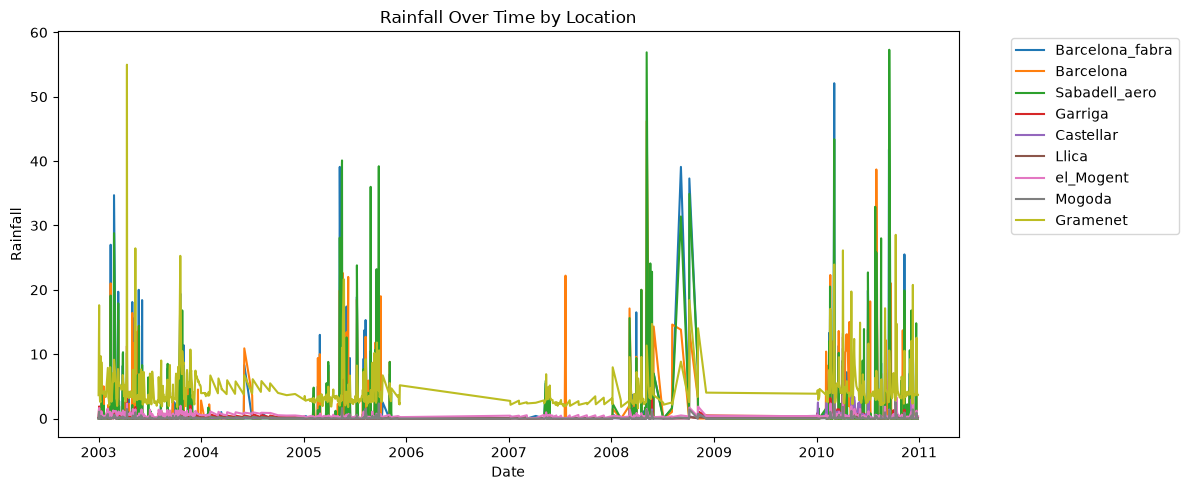

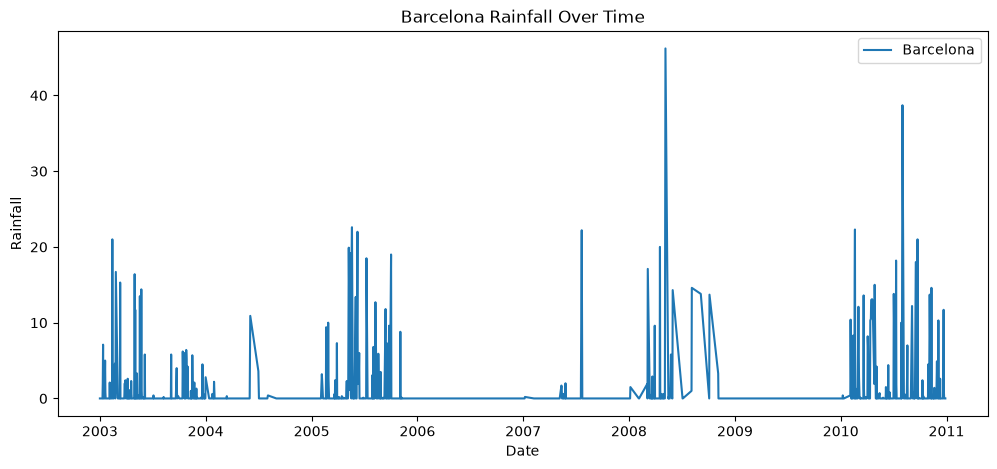

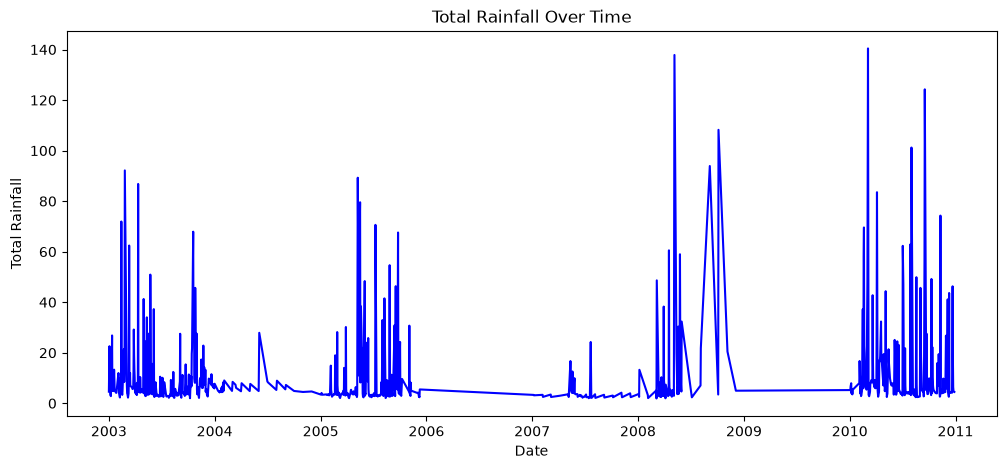

In [12]:
location_cols = [c for c in df.columns if c != "fecha"]
 
plt.figure(figsize=(12, 5))
for col in location_cols:
    plt.plot(df["fecha"], df[col], label=col)
plt.xlabel("Date")
plt.ylabel("Rainfall")
plt.title("Rainfall Over Time by Location")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
 
if "Barcelona" in df.columns:  # FIX: guard against the column not existing
    plt.figure(figsize=(12, 5))
    plt.plot(df["fecha"], df["Barcelona"], label="Barcelona")
    plt.xlabel("Date")
    plt.ylabel("Rainfall")
    plt.title("Barcelona Rainfall Over Time")
    plt.legend()
    plt.show()
 
df["total_rainfall"] = df[location_cols].sum(axis=1)
 
plt.figure(figsize=(12, 5))
plt.plot(df["fecha"], df["total_rainfall"], color="blue")
plt.xlabel("Date")
plt.ylabel("Total Rainfall")
plt.title("Total Rainfall Over Time")
plt.show()

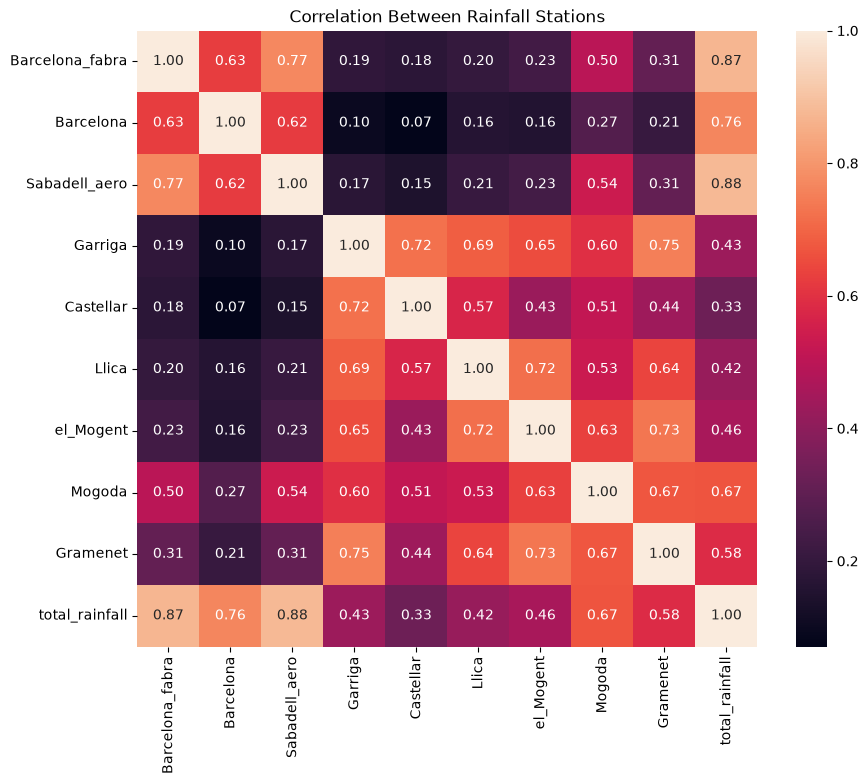

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f")
plt.title("Correlation Between Rainfall Stations")  # FIX: this is a correlation
plt.show()      

In [14]:
# ---------------------------------------------------------------------------
target_station = "Barcelona_fabra" if "Barcelona_fabra" in df.columns else location_cols[0]  # FIX: guard
 
df["rainfall_lag1"] = df[target_station].shift(1)
df["rainfall_lag2"] = df[target_station].shift(2)
df["rainfall_lag3"] = df[target_station].shift(3)

No 'runoff' column found in the data — creating a synthetic placeholder target for demonstration. Replace this with real observed runoff/streamflow data for a meaningful model.


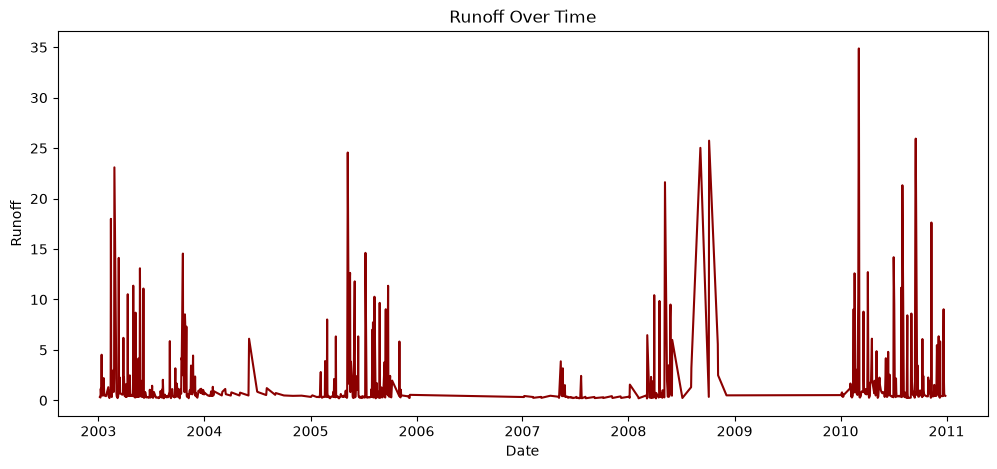

In [15]:
if "runoff" not in df.columns:
    print(
        "No 'runoff' column found in the data — creating a synthetic "
        "placeholder target for demonstration. Replace this with real "
        "observed runoff/streamflow data for a meaningful model."
    )
    df["runoff"] = df[target_station] * 0.4 + df["total_rainfall"] * 0.1
 
df["runoff_lag1"] = df["runoff"].shift(1)
df = df.dropna().reset_index(drop=True)
 
plt.figure(figsize=(12, 5))
plt.plot(df["fecha"], df["runoff"], color="darkred")
plt.xlabel("Date")
plt.ylabel("Runoff")
plt.title("Runoff Over Time")
plt.show()
 
feature_cols = ["total_rainfall", "rainfall_lag1", "rainfall_lag2", "rainfall_lag3", "runoff_lag1"]
X = df[feature_cols]
y = df["runoff"]
 

In [16]:
split = int(len(X) * 0.8)  # FIX: was `int(len(df) * 0.8)`; use len(X) so it stays correct even if row counts diverge
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
 

In [18]:
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name:20s} | MAE: {mae:8.3f}  RMSE: {rmse:8.3f}  R2: {r2:6.3f}")
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2}
 
 
model_lr = LinearRegression().fit(X_train, y_train)
pred_lr = model_lr.predict(X_test)
 
model_rf = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train, y_train)
pred_rf = model_rf.predict(X_test)
 
model_xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42).fit(X_train, y_train)
pred_xgb = model_xgb.predict(X_test)
 
print("\nBASELINE MODEL RESULTS")
baseline_results = [
    evaluate("Linear Regression", y_test, pred_lr),  # FIX: originally only Random Forest was ever scored
    evaluate("Random Forest", y_test, pred_rf),
    evaluate("XGBoost", y_test, pred_xgb),
]
print(pd.DataFrame(baseline_results).to_string(index=False))
 
 


BASELINE MODEL RESULTS
Linear Regression    | MAE:    0.436  RMSE:    1.097  R2:  0.911
Random Forest        | MAE:    0.381  RMSE:    1.247  R2:  0.885
XGBoost              | MAE:    0.463  RMSE:    1.486  R2:  0.837
            Model      MAE     RMSE       R2
Linear Regression 0.435755 1.096811 0.911015
    Random Forest 0.380711 1.247072 0.884963
          XGBoost 0.462505 1.485774 0.836710


In [19]:
seq_length = 7

scaler_X = StandardScaler().fit(X_train)
scaler_y = StandardScaler().fit(y_train.values.reshape(-1, 1))
 
X_scaled_train = scaler_X.transform(X_train)
X_scaled_test = scaler_X.transform(X_test)
y_scaled_train = scaler_y.transform(y_train.values.reshape(-1, 1))
y_scaled_test = scaler_y.transform(y_test.values.reshape(-1, 1))
 
 
def make_sequences(X_arr, y_arr, seq_len):
    X_seq, y_seq = [], []
    for i in range(len(X_arr) - seq_len):
        X_seq.append(X_arr[i:i + seq_len])
        y_seq.append(y_arr[i + seq_len])
    return np.array(X_seq), np.array(y_seq)
 

In [20]:
X_train_seq, y_train_seq = make_sequences(X_scaled_train, y_scaled_train, seq_length)
X_test_seq, y_test_seq = make_sequences(X_scaled_test, y_scaled_test, seq_length)
 
n_features = X_train_seq.shape[2]
 
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(seq_length, n_features)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1),
])
lstm_model.compile(optimizer="adam", loss="mse", metrics=["mae"])
 
history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_seq, y_test_seq),
    verbose=1,
)
 

c:\Users\PCSDIR\anaconda3\envs\ml311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 90ms/step - loss: 0.9983 - mae: 0.4892 - val_loss: 1.3639 - val_mae: 0.5783
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.9898 - mae: 0.4724 - val_loss: 1.3628 - val_mae: 0.5686
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.9935 - mae: 0.4658 - val_loss: 1.3541 - val_mae: 0.5732
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.9855 - mae: 0.4637 - val_loss: 1.3658 - val_mae: 0.5880
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.9850 - mae: 0.4748 - val_loss: 1.3633 - val_mae: 0.5876
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.9812 - mae: 0.4773 - val_loss: 1.3657 - val_mae: 0.5988
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.9809 - mae: 0.4808 - val_loss: 1.3411 - val_mae: 0.5867
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.9788 - mae: 0.4737 - val_loss: 1.3703 - val_mae: 0.5889
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.97

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 474ms/step

FINAL MODEL COMPARISON (real runoff units)
Random Forest        | MAE:    1.936  RMSE:    4.056  R2: -0.181
XGBoost              | MAE:    1.925  RMSE:    4.319  R2: -0.340
LSTM                 | MAE:    1.903  RMSE:    3.882  R2: -0.082
        Model      MAE     RMSE        R2
Random Forest 1.935877 4.056005 -0.181362
      XGBoost 1.925332 4.319397 -0.339775
         LSTM 1.902698 3.882377 -0.082383


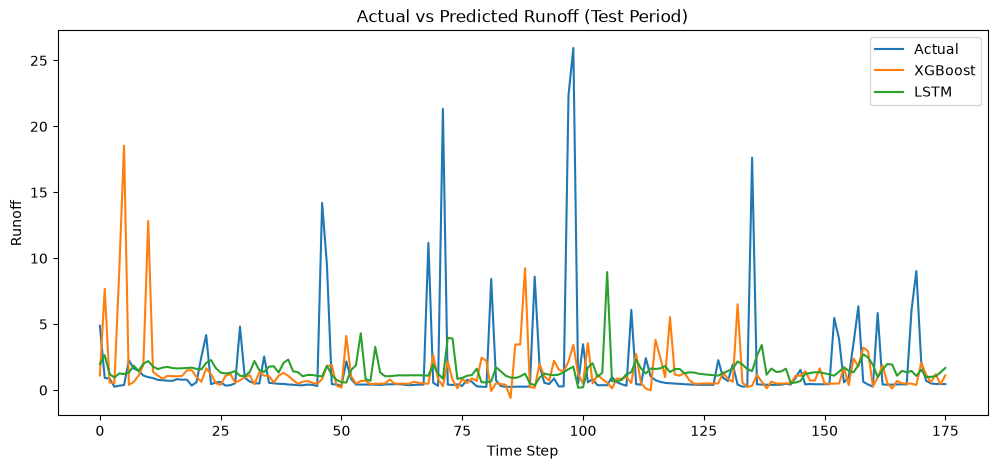

In [21]:
X_train_last = X_train_seq[:, -1, :]
X_test_last = X_test_seq[:, -1, :]
 
rf_seq = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train_last, y_train_seq.ravel())
xgb_seq = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42).fit(
    X_train_last, y_train_seq.ravel()
)
 
rf_pred_scaled = rf_seq.predict(X_test_last).reshape(-1, 1)
xgb_pred_scaled = xgb_seq.predict(X_test_last).reshape(-1, 1)
lstm_pred_scaled = lstm_model.predict(X_test_seq).reshape(-1, 1)
 
y_test_real = scaler_y.inverse_transform(y_test_seq).flatten()
rf_pred_real = scaler_y.inverse_transform(rf_pred_scaled).flatten()
xgb_pred_real = scaler_y.inverse_transform(xgb_pred_scaled).flatten()
lstm_pred_real = scaler_y.inverse_transform(lstm_pred_scaled).flatten()
 
print("\nFINAL MODEL COMPARISON (real runoff units)")
final_results = [
    evaluate("Random Forest", y_test_real, rf_pred_real),
    evaluate("XGBoost", y_test_real, xgb_pred_real),
    evaluate("LSTM", y_test_real, lstm_pred_real),  # FIX: original only ever printed LSTM's R², never its MAE/RMSE
]
print(pd.DataFrame(final_results).to_string(index=False))
 
plt.figure(figsize=(12, 5))
plt.plot(y_test_real, label="Actual")
plt.plot(xgb_pred_real, label="XGBoost")
plt.plot(lstm_pred_real, label="LSTM")
plt.title("Actual vs Predicted Runoff (Test Period)")
plt.xlabel("Time Step")
plt.ylabel("Runoff")
plt.legend()
plt.show()
 
 

In [22]:
joblib.dump(xgb_seq, "runoff_xgboost.pkl")
lstm_model.save("runoff_lstm.keras")
joblib.dump(scaler_X, "scaler_x.pkl")
joblib.dump(scaler_y, "scaler_y.pkl")
 
print("\nTraining complete. Models and scalers saved successfully.")
 


Training complete. Models and scalers saved successfully.
